# Análisis de Series Temporales con Python

**Mayo 2026 · Bloque V**

## Objetivos
- Preparar datos temporales con índice de fecha
- Crear variables rezagadas y rolling features
- Comparar un baseline con un modelo supervisado de forecasting

## Preparación
Ejecuta la primera celda para cargar librerías. Si falta alguna librería, instálala desde el entorno con `pip install -r requirements.txt`.

## Carga y visualización

,demanda
fecha,
2025-01-01,118.90
2025-01-02,112.72
2025-01-03,128.25
2025-01-04,122.48
2025-01-05,126.53


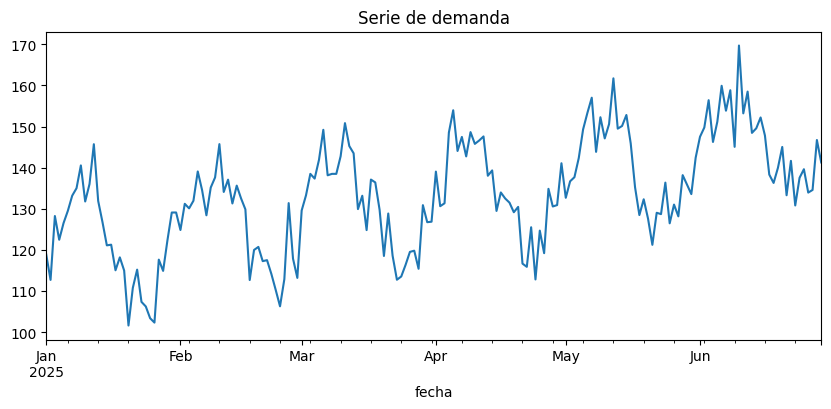

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../datasets")
pd.set_option("display.max_columns", 50)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv(DATA_DIR / "serie_demanda.csv", parse_dates=["fecha"]).set_index("fecha")
display(df.head())
df["demanda"].plot(figsize=(10,4), title="Serie de demanda")
plt.show()

## Baseline ingenuo

In [4]:
df_eval = df.copy()
df_eval["naive_pred"] = df_eval["demanda"].shift(1)
eval_naive = df_eval.dropna()
print("MAE baseline:", round(mean_absolute_error(eval_naive["demanda"], eval_naive["naive_pred"]), 2))

MAE baseline: 6.19


## Features temporales

In [5]:
feat = df.copy()
for lag in [1, 2, 7, 14, 30]:
    feat[f"lag_{lag}"] = feat["demanda"].shift(lag)
feat["rolling_7"] = feat["demanda"].shift(1).rolling(7).mean()
feat["dia_semana"] = feat.index.dayofweek
feat["mes"] = feat.index.month
feat = feat.dropna()
display(feat.head())

,demanda,lag_1,lag_2,lag_7,lag_14,lag_30,rolling_7,dia_semana,mes
fecha,,,,,,,,,
2025-01-31,129.11,129.10,122.37,106.26,115.06,118.90,113.718571,4,1
2025-02-01,124.85,129.11,129.10,103.40,118.20,112.72,116.982857,5,2
2025-02-02,131.22,124.85,129.11,102.34,114.99,128.25,120.047143,6,2
2025-02-03,130.11,131.22,124.85,117.65,101.63,122.48,124.172857,0,2
2025-02-04,131.96,130.11,131.22,114.91,110.78,126.53,125.952857,1,2


## Random Forest forecasting

MAE RF: 5.99
RMSE RF: 7.58


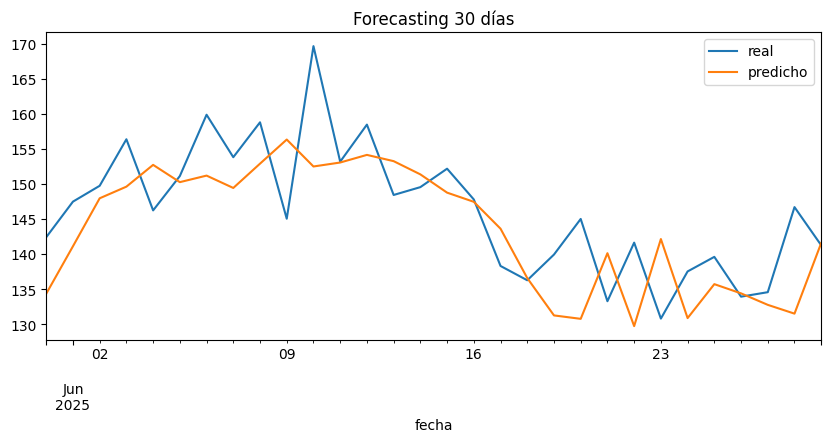

In [8]:
train = feat.iloc[:-30]
test = feat.iloc[-30:]

# Separación de variables
X_train, y_train = train.drop(columns=["demanda"]), train["demanda"]
X_test, y_test = test.drop(columns=["demanda"]), test["demanda"]

# Modelo
model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

# Predicción
pred = model.predict(X_test)

# Predicción
pred = model.predict(X_test)

# MAE
mae = mean_absolute_error(y_test, pred)

# RMSE (calculado manualmente para evitar errores de versión)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE RF:", round(mae, 2))
print("RMSE RF:", round(rmse, 2))

# Gráfico
pd.DataFrame({
    "real": y_test,
    "predicho": pred
}, index=y_test.index).plot(figsize=(10,4), title="Forecasting 30 días")

plt.show()

## Actividad entregable
1. Modifica el dataset o hiperparámetros.
2. Añade una breve interpretación de resultados.
3. Guarda el notebook ejecutado y exporta una versión HTML/PDF si se solicita.